# Quantum-preconditioned vs baseline (Gurobi)

This notebook reads a results CSV produced by `scripts/run_experiment.py` and plots **approximation ratio vs penalty**, aggregated over **multiple seeds** (mean ± SEM).

Approximation ratio here is defined as:

$$\mathrm{ratio}(s,\lambda)=\frac{f_\mathrm{orig}(z_{s,\lambda})}{f_\mathrm{orig}(z_{s,\mathrm{base}})}$$

where $f_\mathrm{orig}$ is the original (baseline) objective, $z_{s,\lambda}$ is the solution found by the preconditioned model for penalty $\lambda$, and $z_{s,\mathrm{base}}$ is the baseline solution for that seed $s$.

The code is flexible to missing seeds and non-uniform penalty grids.

In [1]:
from pathlib import Path
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# --------------------
# User-config settings
# --------------------
N = 20
LAYERS = 1
RUN_SOLVES = False

DATA_ROOT = Path('../one_equality/complete_random')
results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)

# List one or more CSVs to load and concatenate (useful for presolve comparison).
CSV_PATHS = [
    f"../results/N={N}_presolve_on.csv",
    f"../results/N={N}_presolve_off.csv",
]

pen_re = re.compile(r"preconditioned_problem_pen=(?P<pen>[0-9]+\.[0-9]+)\.dat$")

if RUN_SOLVES:
    from qp_gurobi.solve import solve_from_paths

    SEEDS = None
    MAX_SEEDS = None

    n_dir = DATA_ROOT / f'N={N}'
    if SEEDS is None:
        seeds = sorted(
            int(p.name.split('=', 1)[1])
            for p in sorted(n_dir.glob('seed=*')) if p.is_dir()
        )
    else:
        seeds = list(SEEDS)
    if MAX_SEEDS is not None:
        seeds = seeds[:int(MAX_SEEDS)]

    all_rows = []
    for seed in seeds:
        instance_dir = n_dir / f'seed={seed}'
        baseline_path = instance_dir / 'problem.dat'
        layer_dir = instance_dir / f'n_qaoa_layers={LAYERS}'
        if not baseline_path.exists() or not layer_dir.exists():
            print(f'[WARN] skipping seed={seed}: missing baseline or layer dir')
            continue
        precond = [(float(m.group('pen')), p)
                   for p in sorted(layer_dir.glob('preconditioned_problem_pen=*.dat'))
                   if (m := pen_re.search(p.name))]
        if not precond:
            print(f'[WARN] skipping seed={seed}: no preconditioned files')
            continue
        res = solve_from_paths(baseline_path=baseline_path, preconditioned_paths=precond, output_flag=1)
        for r in res:
            row = r.to_row()
            row['seed'] = int(seed)
            row['layers'] = int(LAYERS)
            all_rows.append(row)

    df = pd.DataFrame(all_rows)
    out_csv = results_dir / f'N={N}_seeds=notebook_layers={LAYERS}.csv'
    df.to_csv(out_csv, index=False)
    print(f'Wrote {len(df)} rows to {out_csv}')
else:
    frames = []
    for path in CSV_PATHS:
        p = Path(path)
        if p.exists():
            frames.append(pd.read_csv(p, dtype={'name': 'string', 'x_bits': 'string', 'z_bits': 'string'}))
            print(f'Loaded {p.name} ({len(frames[-1])} rows)')
        else:
            print(f'[WARN] not found: {p}')
    if not frames:
        raise FileNotFoundError('No CSVs loaded.')
    df = pd.concat(frames, ignore_index=True)

# Restore fixed-width bit strings
if 'n' in df.columns:
    n_max = int(df['n'].max())
    df['x_bits'] = df['x_bits'].str.zfill(n_max)
    df['z_bits'] = df['z_bits'].str.zfill(n_max)

# Filter to selected N and LAYERS
if 'n' in df.columns:
    df = df[df['n'] == N].copy()
if 'layers' in df.columns:
    df = df[df['layers'] == LAYERS].copy()

df


Loaded N=20_presolve_on.csv (500 rows)
Loaded N=20_presolve_off.csv (500 rows)


,name,n,objective_model,objective_baseline,penalty,mip_status,runtime_sec,time_to_best_sec,mip_gap,x_bits,z_bits,sum_z,presolve,seed,layers,data_root
0,baseline,20,91.054300,91.054300,NaN,2,1.313509,0.043080,0.000000,00011101100010100111,---+++-++---+-+--+++,0,True,0,1,/mnt/c/Users/rames102/Desktop/Gurobi_QP/one_eq...
1,precond_pen=0.000,20,-0.519522,91.054300,0.0,2,0.674412,0.018892,0.000000,11100010011101011000,+++---+--+++-+-++---,0,True,0,1,/mnt/c/Users/rames102/Desktop/Gurobi_QP/one_eq...
2,precond_pen=0.200,20,-8.524642,91.054300,0.2,2,0.434410,0.020605,0.000000,00011101100010100111,---+++-++---+-+--+++,0,True,0,1,/mnt/c/Users/rames102/Desktop/Gurobi_QP/one_eq...
3,precond_pen=0.300,20,-11.190335,91.054300,0.3,2,0.200110,0.135112,0.000000,11100010011101011000,+++---+--+++-+-++---,0,True,0,1,/mnt/c/Users/rames102/Desktop/Gurobi_QP/one_eq...
4,precond_pen=0.400,20,-7.597414,91.054300,0.4,2,0.203520,0.202311,0.000000,11100010011101011000,+++---+--+++-+-++---,0,True,0,1,/mnt/c/Users/rames102/Desktop/Gurobi_QP/one_eq...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,precond_pen=0.500,20,-4.289709,81.738934,0.5,2,0.090524,0.014103,0.000000,00101010011011101010,--+-+-+--++-+++-+-+-,0,False,49,1,/mnt/c/Users/rames102/Desktop/Gurobi_QP/one_eq...
996,precond_pen=0.600,20,-3.001969,81.738934,0.6,2,0.125368,0.006934,0.000049,11010101100100010101,++-+-+-++--+---+-+-+,0,False,49,1,/mnt/c/Users/rames102/Desktop/Gurobi_QP/one_eq...
997,precond_pen=0.700,20,-2.358288,81.738934,0.7,2,0.628729,0.011592,0.000000,00101010011011101010,--+-+-+--++-+++-+-+-,0,False,49,1,/mnt/c/Users/rames102/Desktop/Gurobi_QP/one_eq...
998,precond_pen=0.800,20,-1.976135,81.738934,0.8,2,0.830400,0.009000,0.000000,00101010011011101010,--+-+-+--++-+++-+-+-,0,False,49,1,/mnt/c/Users/rames102/Desktop/Gurobi_QP/one_eq...


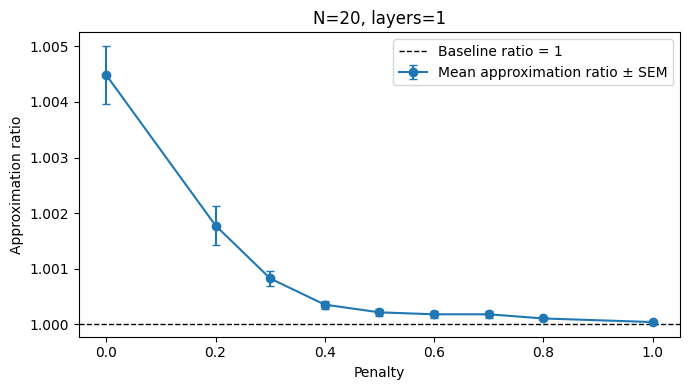

,penalty_round,mean_ratio,std_ratio,n,sem_ratio
0,0.0,1.004485,0.007333,200,0.000519
1,0.2,1.001778,0.004842,200,0.000342
2,0.3,1.000826,0.001856,200,0.000131
3,0.4,1.000355,0.001032,200,0.000073
4,0.5,1.000217,0.000900,200,0.000064
5,0.6,1.000181,0.000873,200,0.000062
6,0.7,1.000181,0.000873,200,0.000062
7,0.8,1.000107,0.000397,200,0.000028
8,1.0,1.000042,0.000206,200,0.000015


In [2]:
# Build per-seed baseline reference and compute approximation ratio per penalty row.
if 'seed' not in df.columns:
    raise ValueError("Expected a 'seed' column in df. Re-run the experiment with multi-seed output (or set RUN_SOLVES=True above).")

# Round penalties to avoid float grouping issues (0.3 vs 0.30000000004).
df = df.copy()
df['penalty_round'] = df['penalty'].round(3)

baseline_rows = df[df['name'] == 'baseline'][['seed', 'objective_baseline', 'runtime_sec']].copy()
baseline_rows = baseline_rows.rename(columns={
    'objective_baseline': 'baseline_obj',
    'runtime_sec': 'baseline_runtime_sec',
})

pre = df[df['penalty'].notna()].copy()
pre = pre.merge(baseline_rows, on='seed', how='left')
pre = pre[pre['baseline_obj'].notna()].copy()
pre = pre[pre['baseline_obj'] != 0].copy()
pre['approx_ratio'] = pre['objective_baseline'] / pre['baseline_obj']

agg = (
    pre.groupby('penalty_round')
    .agg(
        mean_ratio=('approx_ratio', 'mean'),
        std_ratio=('approx_ratio', 'std'),
        n=('approx_ratio', 'count'),
    )
    .reset_index()
    .sort_values('penalty_round')
)
agg['sem_ratio'] = agg['std_ratio'].fillna(0.0) / np.sqrt(agg['n'])

plt.figure(figsize=(7,4))
plt.errorbar(
    agg['penalty_round'],
    agg['mean_ratio'],
    yerr=agg['sem_ratio'],
    fmt='o-',
    capsize=3,
    label='Mean approximation ratio ± SEM',
)
plt.axhline(1.0, color='k', linestyle='--', linewidth=1.0, label='Baseline ratio = 1')
plt.xlabel('Penalty')
plt.ylabel('Approximation ratio')
plt.title(f'N={N}, layers={LAYERS}')
plt.legend()
plt.tight_layout()
plt.show()

agg

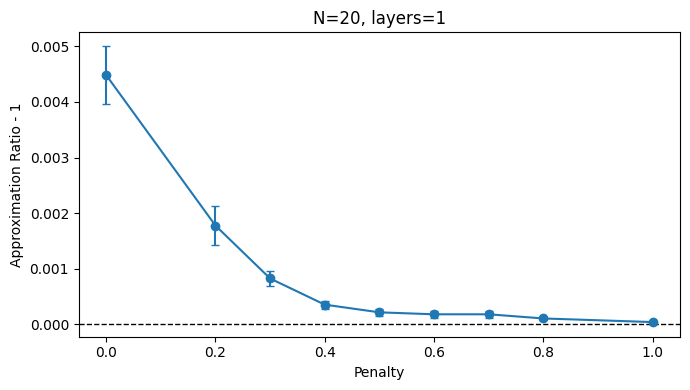

,penalty_round,n,mean_rel_gap,sem_rel_gap
0,0.0,200,0.004485,0.000519
1,0.2,200,0.001778,0.000342
2,0.3,200,0.000826,0.000131
3,0.4,200,0.000355,0.000073
4,0.5,200,0.000217,0.000064
5,0.6,200,0.000181,0.000062
6,0.7,200,0.000181,0.000062
7,0.8,200,0.000107,0.000028
8,1.0,200,0.000042,0.000015


In [3]:
# Relative gap version: ratio - 1 (negative means better than baseline for a minimization objective).
agg_gap = agg[['penalty_round', 'n']].copy()
agg_gap['mean_rel_gap'] = agg['mean_ratio'] - 1
agg_gap['sem_rel_gap'] = agg['sem_ratio']

plt.figure(figsize=(7,4))
plt.errorbar(
    agg_gap['penalty_round'],
    agg_gap['mean_rel_gap'],
    yerr=agg_gap['sem_rel_gap'],
    fmt='o-',
    capsize=3,
)
plt.axhline(0.0, color='k', linestyle='--', linewidth=1.0)
plt.xlabel('Penalty')
plt.ylabel('Approximation Ratio - 1')
plt.title(f'N={N}, layers={LAYERS}')
plt.tight_layout()
plt.show()

agg_gap

/tmp/ipykernel_166338/875049251.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax_rt.legend(); fig_rt.tight_layout(); fig_rt.show()
/tmp/ipykernel_166338/875049251.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax_sp.legend(); fig_sp.tight_layout(); fig_sp.show()


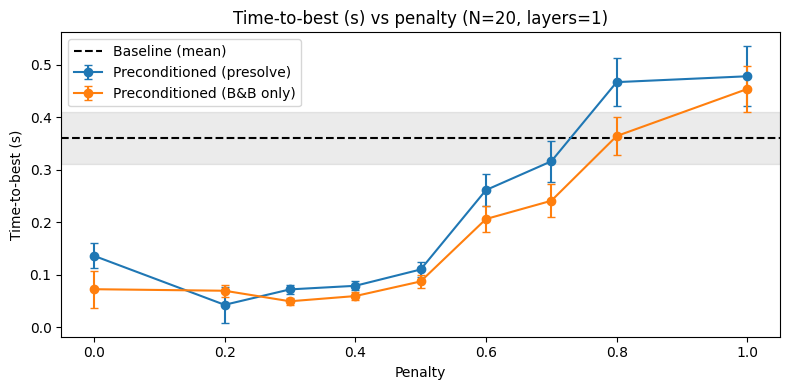

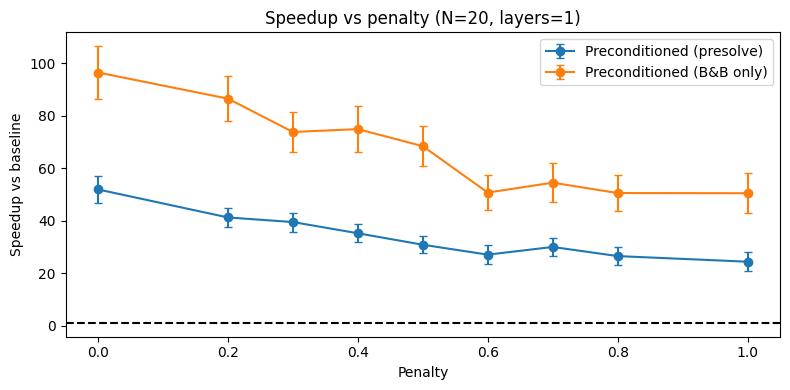

In [4]:
# Toggle between time-to-best-solution and total proof time.
TIME_COL = 'time_to_best_sec'  # swap to 'runtime_sec' to include optimality proof

groups = sorted(df['presolve'].unique(), reverse=True) if 'presolve' in df.columns else [None]
fig_rt, ax_rt = plt.subplots(figsize=(8, 4))
fig_sp, ax_sp = plt.subplots(figsize=(8, 4))

for psv in groups:
    sub = pre[pre['presolve'] == psv].copy() if psv is not None else pre.copy()
    tcol = TIME_COL if TIME_COL in sub.columns else 'runtime_sec'
    sub = sub[sub[tcol].notna() & sub['baseline_runtime_sec'].notna()].copy()
    sub['speedup'] = sub['baseline_runtime_sec'] / sub[tcol]
    lbl = '' if psv is None else (' (presolve)' if psv else ' (B&B only)')

    for agg_col, ax in [(tcol, ax_rt), ('speedup', ax_sp)]:
        g = (sub.groupby('penalty_round')[agg_col]
             .agg(['mean', 'std', 'count']).reset_index().sort_values('penalty_round'))
        g['sem'] = g['std'].fillna(0) / np.sqrt(g['count'])
        ax.errorbar(g['penalty_round'], g['mean'], yerr=g['sem'],
                    fmt='o-', capsize=3, label=f'Preconditioned{lbl}')

# Baseline reference (time_to_best across seeds)
bl_tcol = TIME_COL if TIME_COL in df.columns else 'runtime_sec'
bl_vals = df[df['name'] == 'baseline'][bl_tcol].dropna().astype(float)
bl_mean = float(bl_vals.mean())
bl_sem  = float(bl_vals.std(ddof=1) / np.sqrt(len(bl_vals))) if len(bl_vals) > 1 else 0.0
ax_rt.axhline(bl_mean, color='k', linestyle='--', label='Baseline (mean)')
if bl_sem > 0:
    ax_rt.axhspan(bl_mean - bl_sem, bl_mean + bl_sem, color='k', alpha=0.08)
ax_sp.axhline(1.0, color='k', linestyle='--')

time_label = 'Time-to-best (s)' if bl_tcol == 'time_to_best_sec' else 'Total solve time (s)'
ax_rt.set(xlabel='Penalty', ylabel=time_label,
          title=f'{time_label} vs penalty (N={N}, layers={LAYERS})')
ax_rt.legend(); fig_rt.tight_layout(); fig_rt.show()

ax_sp.set(xlabel='Penalty', ylabel='Speedup vs baseline',
          title=f'Speedup vs penalty (N={N}, layers={LAYERS})')
ax_sp.legend(); fig_sp.tight_layout(); fig_sp.show()